Evaluating using device: cuda
Reading dataset from: /home/aakash/rizwan/NLP_Project/datasets/processed/malayalam_cleaned.csv
Plots will be saved to: /home/aakash/rizwan/NLP_Project/results/jupyter_plots_20260423_091019

--- Evaluating Traditional ML Baselines ---
Evaluating Logistic_Regression...
Evaluating Linear_SVM...
Evaluating Naive_Bayes...
--- Evaluating Transformer: FT_muril ---


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_muril_20260423_041201/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


FT_muril:   0%|          | 0/4 [00:00<?, ?it/s]

--- Evaluating Transformer: FT_indic_bert ---


FT_indic_bert:   0%|          | 0/4 [00:00<?, ?it/s]

...

The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_xlm_roberta_20260423_041201/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


FT_xlm_roberta:   0%|          | 0/4 [00:00<?, ?it/s]

--- Evaluating Untrained Base: Base_XLM_RoBERTa ---


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/offline_models/local_xlm_roberta' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Base_XLM_RoBERTa:   0%|          | 0/4 [00:00<?, ?it/s]

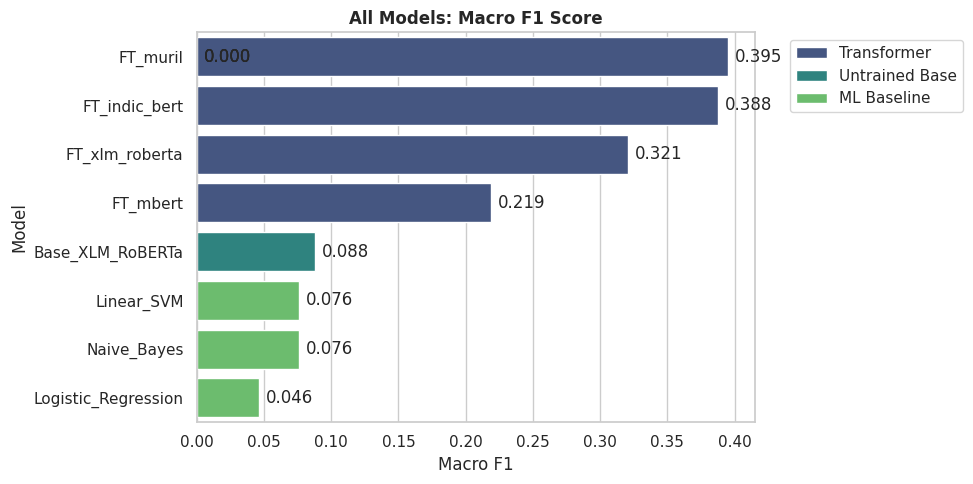

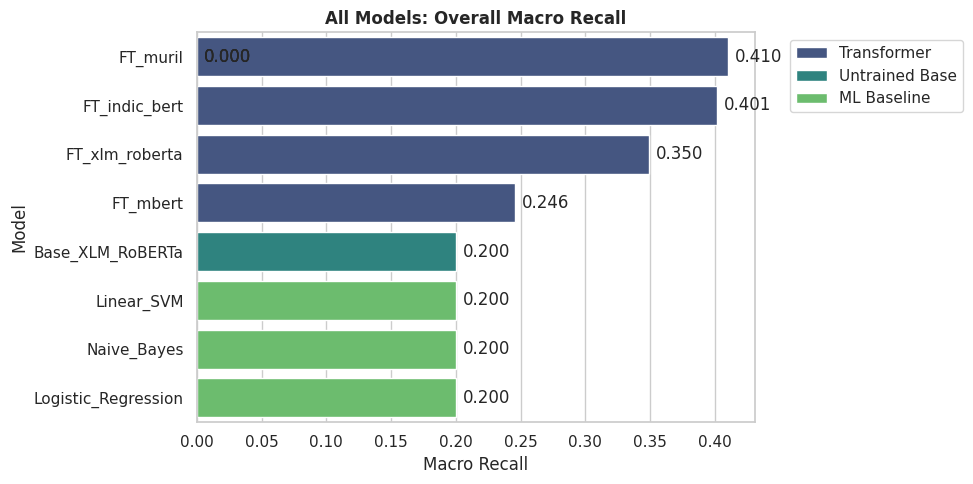

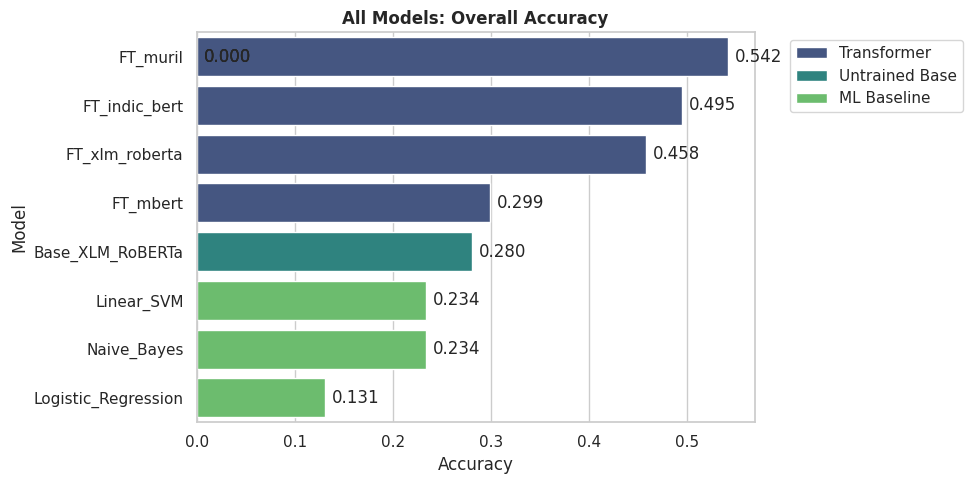

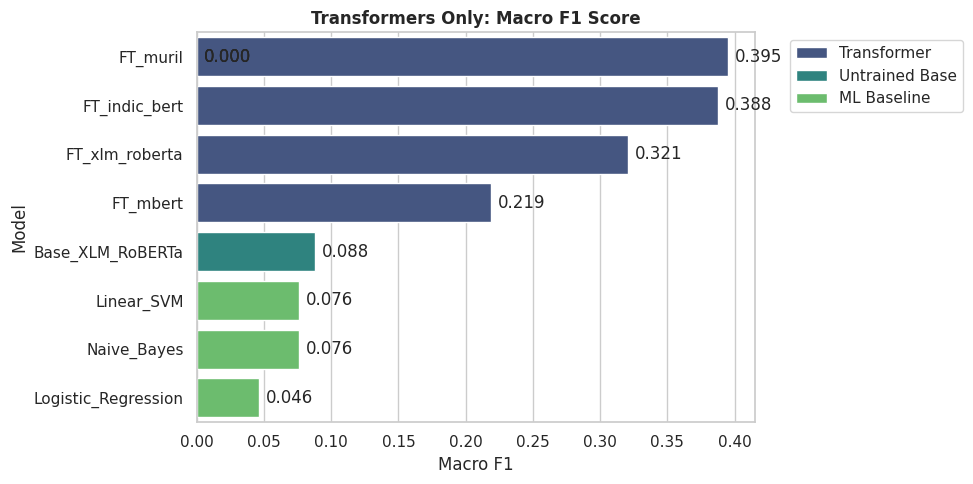

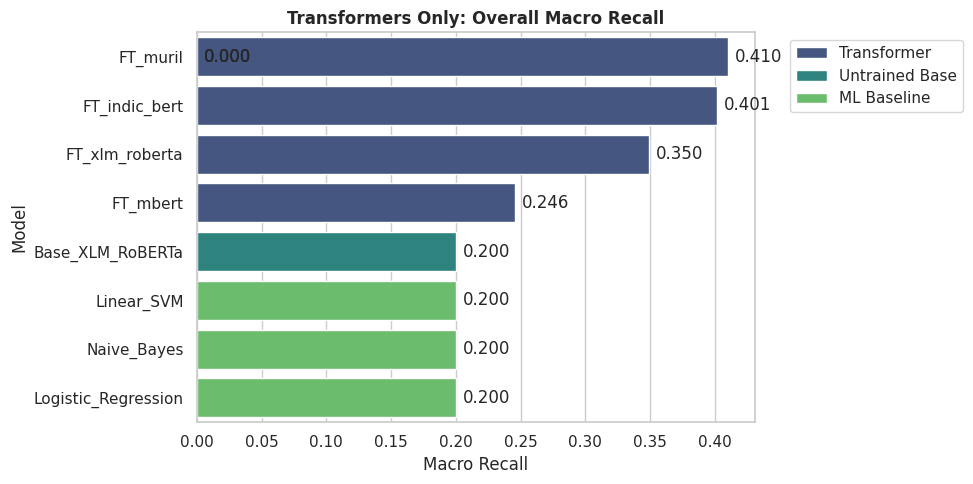

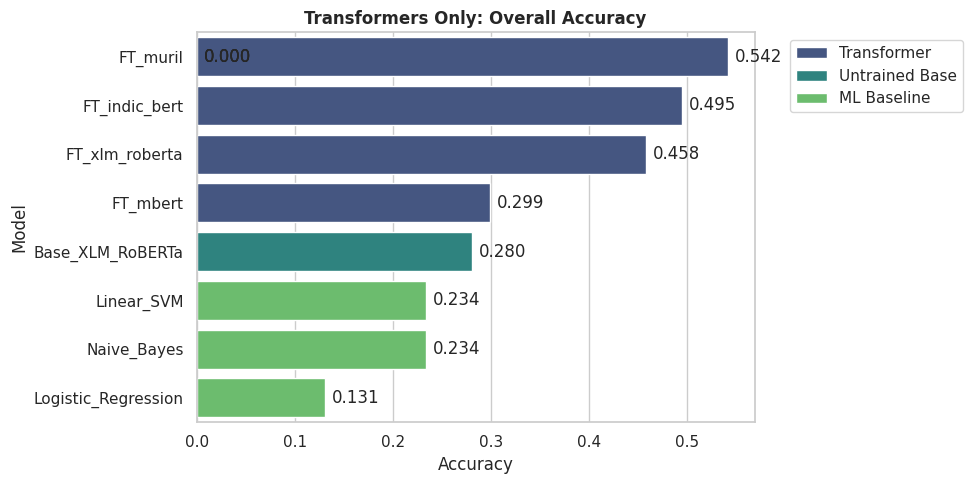

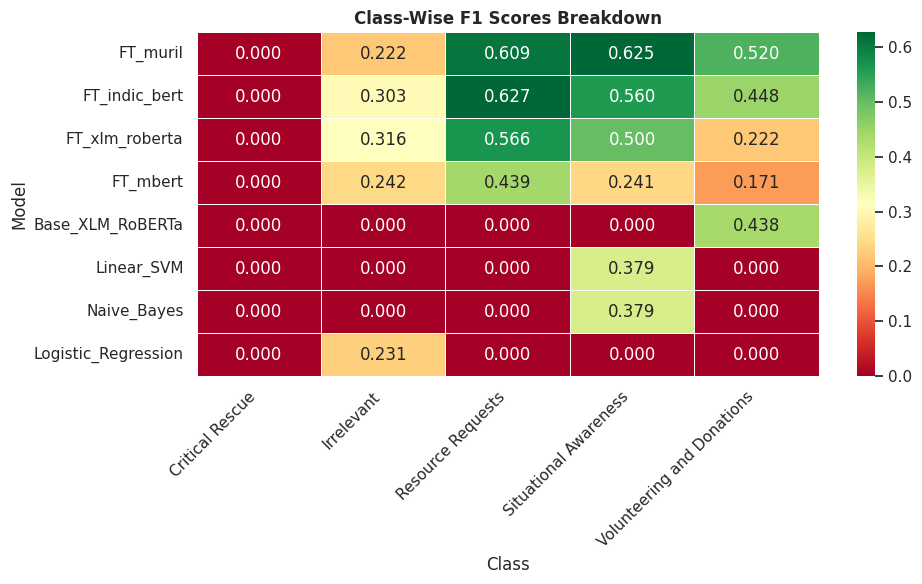

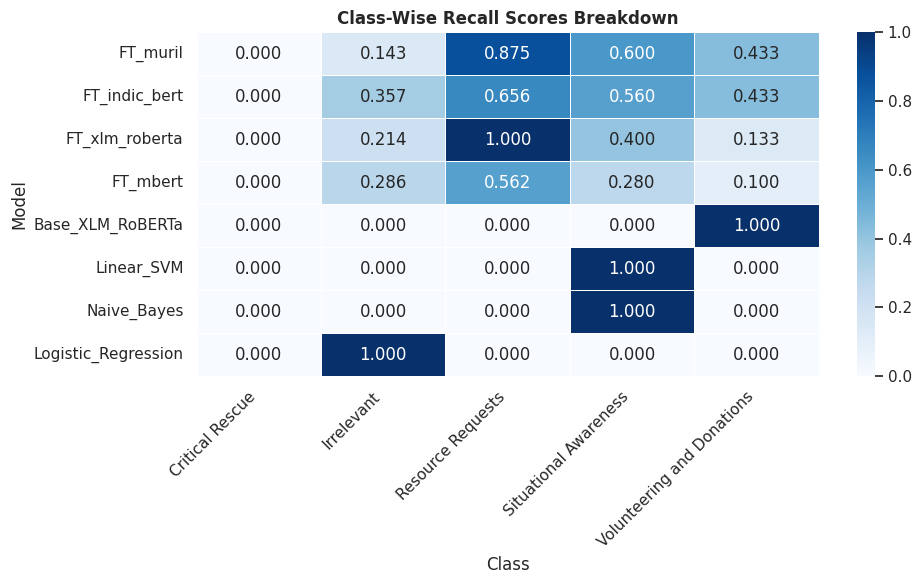


All plots and CSVs successfully saved to: /home/aakash/rizwan/NLP_Project/results/jupyter_plots_20260423_091019


In [3]:
# ==========================================
# CELL 1: Setup, Evaluate, Plot, and Save in Jupyter
# ==========================================
import os
import torch
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm  # Uses Jupyter-friendly progress bars
from datetime import datetime
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import warnings
warnings.filterwarnings('ignore')

# 1. Setup Paths for Jupyter
ROOT_DIR = os.path.abspath("..") 
# IMPORTANT: If you are using the Manglish dataset we just made, change this to "malayalam_manglish.csv"
DATA_PATH = os.path.join(ROOT_DIR, "datasets", "processed", "malayalam_cleaned.csv")
ML_MODELS_DIR = os.path.join(ROOT_DIR, "offline_models", "ml_baselines")
RESULTS_DIR = os.path.join(ROOT_DIR, "results")

# Generate a timestamped folder just for these plots
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
PLOT_DIR = os.path.join(RESULTS_DIR, f"jupyter_plots_{TIMESTAMP}")
os.makedirs(PLOT_DIR, exist_ok=True)

LABEL_NAMES = ['Situational Awareness', 'Critical Rescue', 'Volunteering and Donations', 'Irrelevant', 'Resource Requests']
label2id = {label: i for i, label in enumerate(LABEL_NAMES)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating using device: {device}")
print(f"Reading dataset from: {DATA_PATH}")
print(f"Plots will be saved to: {PLOT_DIR}\n")

# 2. Evaluation Functions
def evaluate_ml_models(df):
    predictions_dict = {}
    print("--- Evaluating Traditional ML Baselines ---")
    vectorizer_path = os.path.join(ML_MODELS_DIR, "tfidf_vectorizer.joblib")
    if not os.path.exists(vectorizer_path):
        return predictions_dict
        
    vectorizer = joblib.load(vectorizer_path)
    X_test = vectorizer.transform(df['text'].astype(str).fillna(''))
    y_test = df['label_id'].values

    for model_name in ["Logistic_Regression", "Linear_SVM", "Random_Forest", "Naive_Bayes"]:
        model_path = os.path.join(ML_MODELS_DIR, f"{model_name}.joblib")
        if os.path.exists(model_path):
            print(f"Evaluating {model_name}...")
            model = joblib.load(model_path)
            y_pred = model.predict(X_test)
            y_pred_ids = [label2id.get(label, -1) for label in y_pred]
            predictions_dict[model_name] = {"y_true": y_test, "y_pred": y_pred_ids, "type": "ML Baseline"}
    return predictions_dict

def evaluate_transformer(model_name, model_path, df, model_type="Transformer"):
    print(f"--- Evaluating {model_type}: {model_name} ---")
    if not os.path.exists(model_path): return None

    use_fast = False if "indic_bert" in model_name.lower() else True
    tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=use_fast)
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=5).to(device)
    model.eval()

    texts = df['text'].astype(str).tolist()
    y_true = df['label_id'].values
    y_pred = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), 32), desc=model_name):
            inputs = tokenizer(texts[i:i+32], padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
            logits = model(**inputs).logits
            y_pred.extend(torch.argmax(logits, dim=-1).cpu().numpy())

    del model, tokenizer
    torch.cuda.empty_cache()
    return {"y_true": list(y_true), "y_pred": list(y_pred), "type": model_type}

# 3. Execution
df = pd.read_csv(DATA_PATH)
df['label_id'] = df['label'].map(label2id)
df = df.dropna(subset=['label_id'])
df['label_id'] = df['label_id'].astype(int)

model_predictions = evaluate_ml_models(df)

transformers = ["local_muril", "local_indic_bert", "local_mbert", "local_xlm_roberta"]
for t_name in transformers:
    dirs = [d for d in os.listdir(RESULTS_DIR) if t_name in d and os.path.isdir(os.path.join(RESULTS_DIR, d, "final_model"))]
    if dirs:
        t_path = os.path.join(RESULTS_DIR, sorted(dirs)[-1], "final_model")
        res = evaluate_transformer(f"FT_{t_name.replace('local_', '')}", t_path, df)
        if res: model_predictions[f"FT_{t_name.replace('local_', '')}"] = res

res_base = evaluate_transformer("Base_XLM_RoBERTa", os.path.join(ROOT_DIR, "offline_models", "local_xlm_roberta"), df, "Untrained Base")
if res_base: model_predictions["Base_XLM_RoBERTa"] = res_base

# 4. Process Metrics
overall_metrics, class_f1_scores, class_recall_scores = [], [], []

for name, data in model_predictions.items():
    yt, yp, mtype = data['y_true'], data['y_pred'], data['type']
    p, r, f1, _ = precision_recall_fscore_support(yt, yp, average='macro', zero_division=0)
    acc = accuracy_score(yt, yp)
    overall_metrics.append({"Model": name, "Type": mtype, "Accuracy": acc, "Macro Recall": r, "Macro F1": f1})
    
    _, class_r, class_f1, _ = precision_recall_fscore_support(yt, yp, labels=range(5), zero_division=0)
    for i, class_name in enumerate(LABEL_NAMES):
        class_f1_scores.append({"Model": name, "Class": class_name, "Score": class_f1[i]})
        class_recall_scores.append({"Model": name, "Class": class_name, "Score": class_r[i]})

results_df = pd.DataFrame(overall_metrics).sort_values("Macro F1", ascending=False)
f1_df = pd.DataFrame(class_f1_scores).pivot(index="Model", columns="Class", values="Score").reindex(results_df["Model"])
recall_df = pd.DataFrame(class_recall_scores).pivot(index="Model", columns="Class", values="Score").reindex(results_df["Model"])

# Save the raw metrics to CSVs as well
results_df.to_csv(os.path.join(PLOT_DIR, "overall_metrics.csv"), index=False)
f1_df.to_csv(os.path.join(PLOT_DIR, "classwise_f1.csv"))
recall_df.to_csv(os.path.join(PLOT_DIR, "classwise_recall.csv"))

# ==========================================
# 5. INLINE PLOTTING AND SAVING
# ==========================================
sns.set_theme(style="whitegrid")

def plot_bar(data, x_col, title, filename):
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=data, x=x_col, y="Model", hue="Type", dodge=False, palette="viridis")
    plt.title(title, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    for p in ax.patches:
        if not np.isnan(p.get_width()):
            ax.annotate(f"{p.get_width():.3f}", (p.get_width(), p.get_y() + p.get_height() / 2.), xytext=(5, 0), textcoords='offset points', va='center')
    plt.tight_layout()
    # Save before showing! Use bbox_inches='tight' so the legend doesn't get cut off
    plt.savefig(os.path.join(PLOT_DIR, filename), dpi=300, bbox_inches='tight') 
    plt.show()

def plot_heatmap(data, title, filename, cmap="RdYlGn"):
    plt.figure(figsize=(10, 6))
    sns.heatmap(data, annot=True, cmap=cmap, fmt='.3f', linewidths=.5)
    plt.title(title, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, filename), dpi=300, bbox_inches='tight')
    plt.show()

# A. ALL MODELS: F1, Recall, & Accuracy
plot_bar(results_df, "Macro F1", "All Models: Macro F1 Score", "all_models_f1.png")
plot_bar(results_df.sort_values("Macro Recall", ascending=False), "Macro Recall", "All Models: Overall Macro Recall", "all_models_recall.png")
plot_bar(results_df.sort_values("Accuracy", ascending=False), "Accuracy", "All Models: Overall Accuracy", "all_models_accuracy.png")

# B. TRANSFORMERS ONLY: F1, Recall, & Accuracy
transformers_df = results_df[results_df["Type"].str.contains("Transformer|Base")]
plot_bar(transformers_df, "Macro F1", "Transformers Only: Macro F1 Score", "transformers_only_f1.png")
plot_bar(transformers_df.sort_values("Macro Recall", ascending=False), "Macro Recall", "Transformers Only: Overall Macro Recall", "transformers_only_recall.png")
plot_bar(transformers_df.sort_values("Accuracy", ascending=False), "Accuracy", "Transformers Only: Overall Accuracy", "transformers_only_accuracy.png")

# C. CLASS-WISE HEATMAPS (All Models)
plot_heatmap(f1_df, "Class-Wise F1 Scores Breakdown", "classwise_f1_heatmap.png")
plot_heatmap(recall_df, "Class-Wise Recall Scores Breakdown", "classwise_recall_heatmap.png", cmap="Blues")

print(f"\nAll plots and CSVs successfully saved to: {PLOT_DIR}")

Evaluating using device: cuda
Reading dataset from: /home/aakash/rizwan/NLP_Project/datasets/processed/malayalam_manglish.csv
Plots will be saved to: /home/aakash/rizwan/NLP_Project/results/jupyter_plots_manglish_20260423_091155

--- Evaluating Traditional ML Baselines ---
Evaluating Logistic_Regression...
Evaluating Linear_SVM...
Evaluating Naive_Bayes...
--- Evaluating Transformer: FT_muril ---


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_muril_20260423_041201/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


FT_muril:   0%|          | 0/4 [00:00<?, ?it/s]

--- Evaluating Transformer: FT_indic_bert ---


FT_indic_bert:   0%|          | 0/4 [00:00<?, ?it/s]

...

The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_xlm_roberta_20260423_041201/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


FT_xlm_roberta:   0%|          | 0/4 [00:00<?, ?it/s]

--- Evaluating Untrained Base: Base_XLM_RoBERTa ---


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/offline_models/local_xlm_roberta' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Base_XLM_RoBERTa:   0%|          | 0/4 [00:00<?, ?it/s]

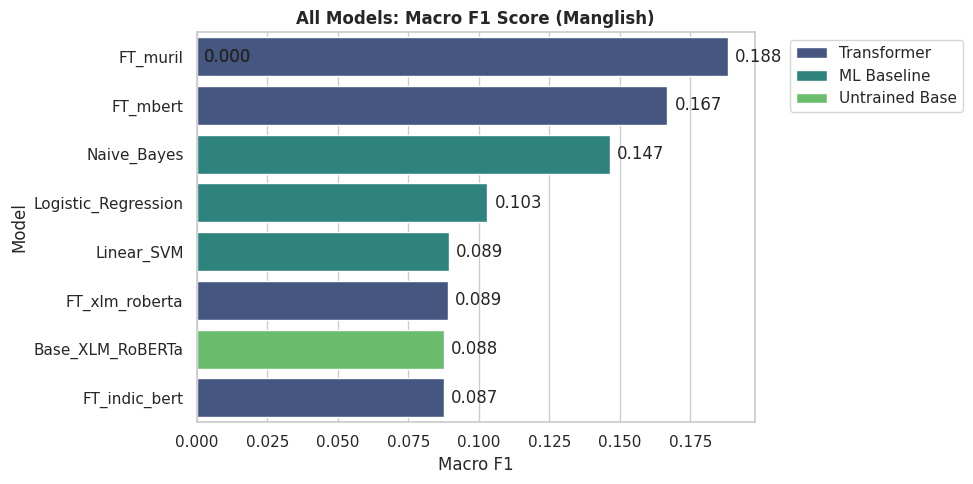

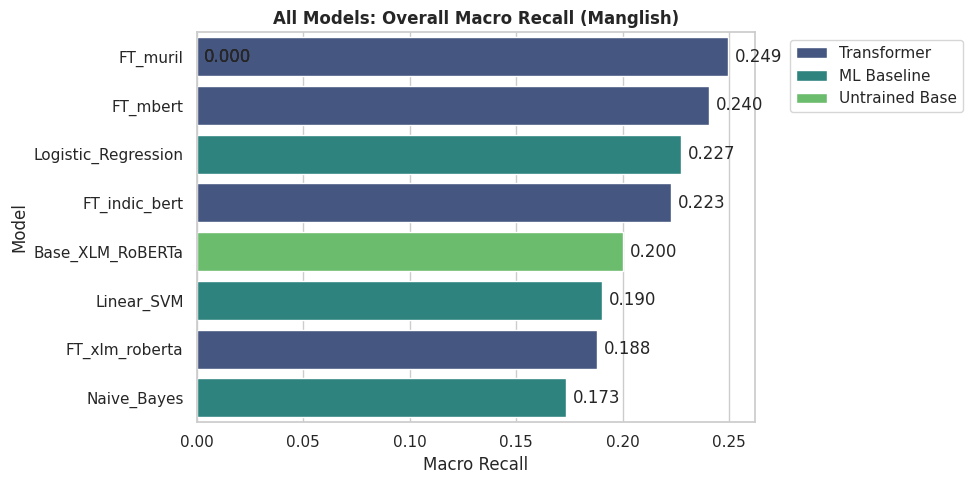

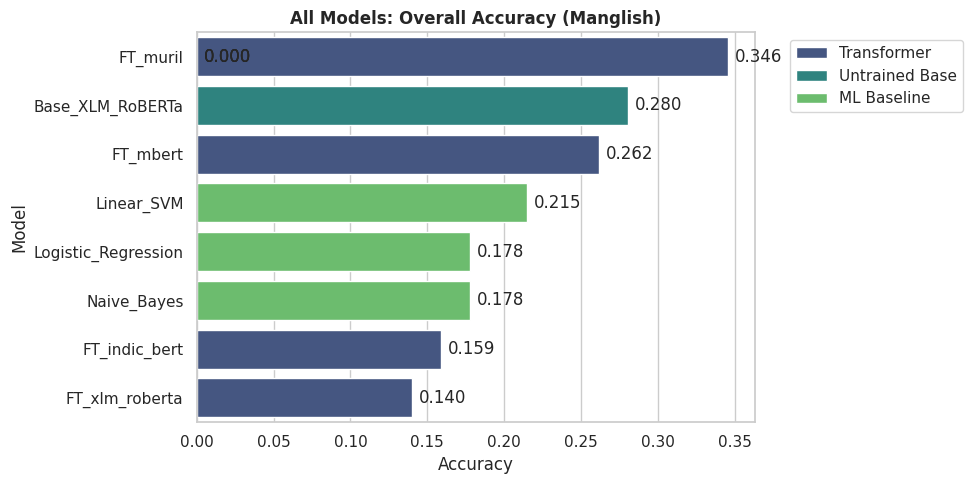

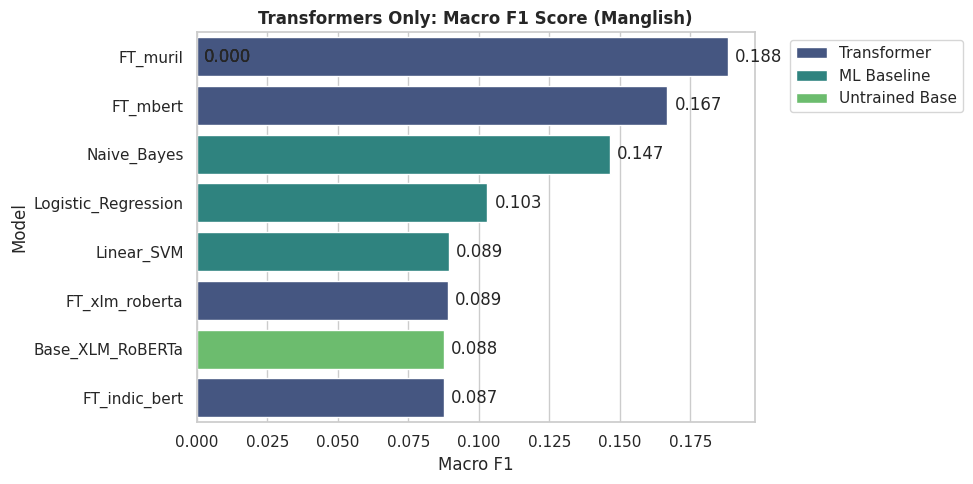

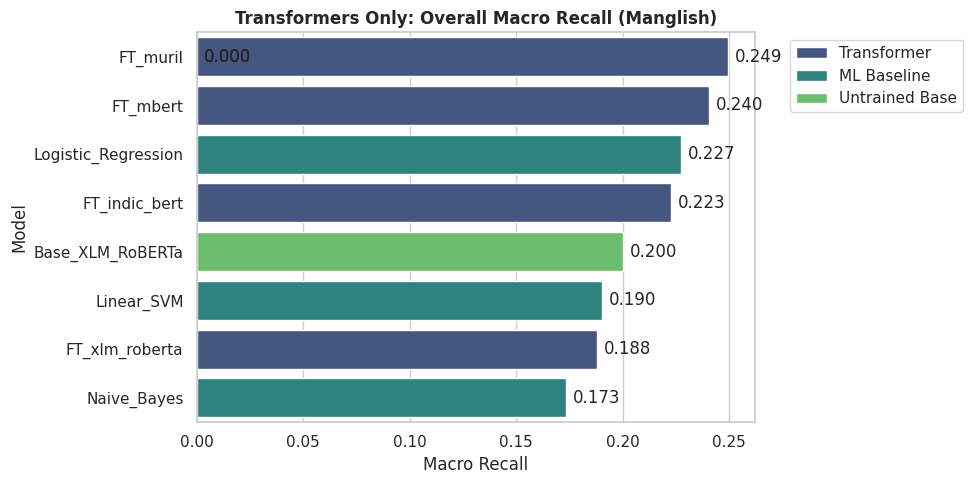

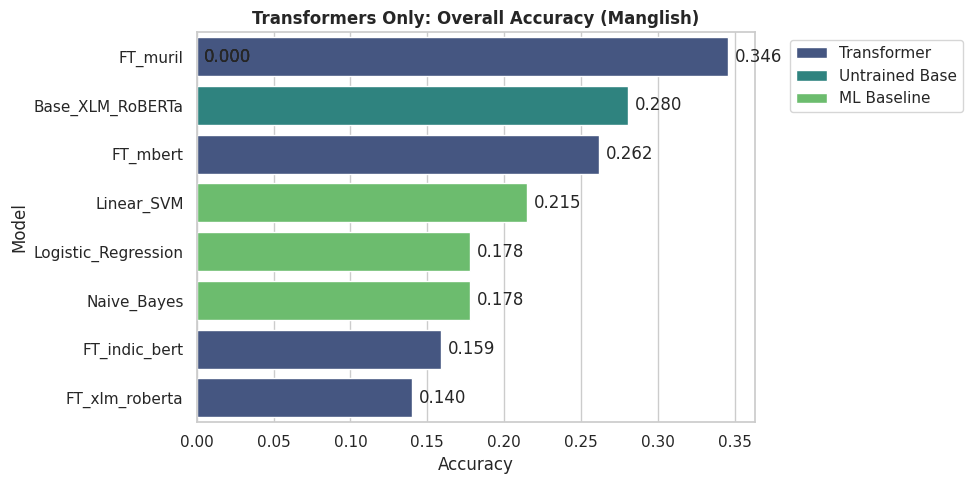

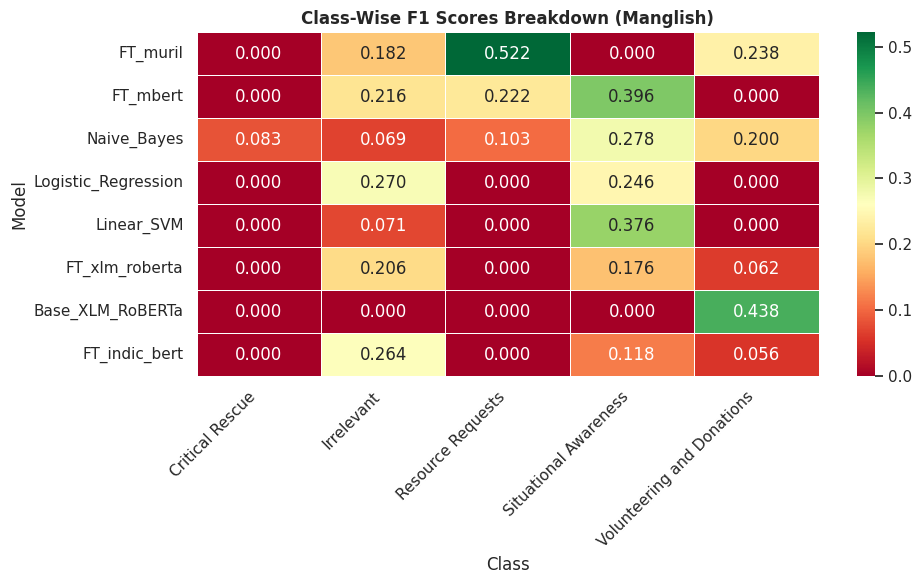

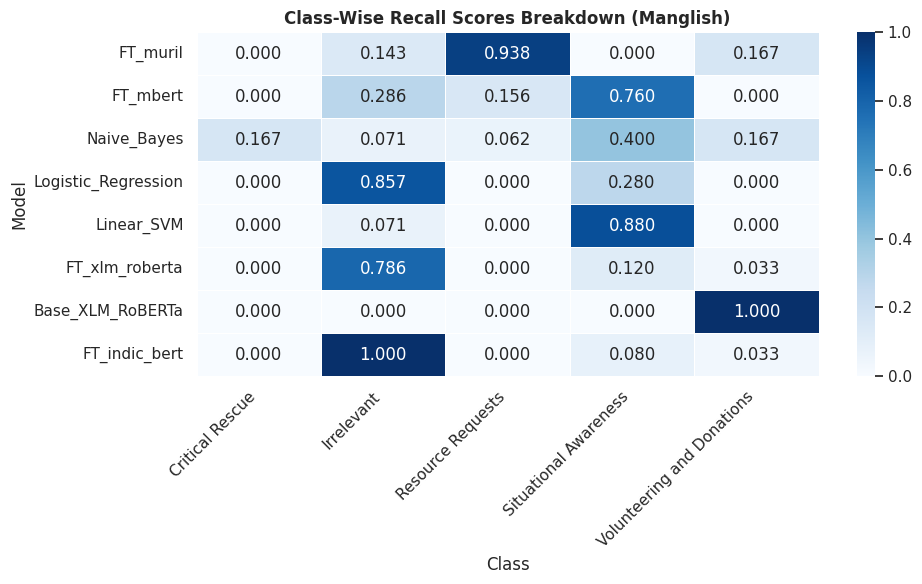


All plots and CSVs successfully saved to: /home/aakash/rizwan/NLP_Project/results/jupyter_plots_manglish_20260423_091155


In [4]:
# ==========================================
# CELL 2: Setup, Evaluate, Plot, and Save (MANGLISH DATASET)
# ==========================================
import os
import torch
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm  # Uses Jupyter-friendly progress bars
from datetime import datetime
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import warnings
warnings.filterwarnings('ignore')

# 1. Setup Paths for Jupyter
ROOT_DIR = os.path.abspath("..") 
# IMPORTANT: Pointing to the new Manglish dataset!
DATA_PATH = os.path.join(ROOT_DIR, "datasets", "processed", "malayalam_manglish.csv")
ML_MODELS_DIR = os.path.join(ROOT_DIR, "offline_models", "ml_baselines")
RESULTS_DIR = os.path.join(ROOT_DIR, "results")

# Generate a timestamped folder just for these Manglish plots
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
PLOT_DIR = os.path.join(RESULTS_DIR, f"jupyter_plots_manglish_{TIMESTAMP}")
os.makedirs(PLOT_DIR, exist_ok=True)

LABEL_NAMES = ['Situational Awareness', 'Critical Rescue', 'Volunteering and Donations', 'Irrelevant', 'Resource Requests']
label2id = {label: i for i, label in enumerate(LABEL_NAMES)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating using device: {device}")
print(f"Reading dataset from: {DATA_PATH}")
print(f"Plots will be saved to: {PLOT_DIR}\n")

# 2. Evaluation Functions
def evaluate_ml_models(df):
    predictions_dict = {}
    print("--- Evaluating Traditional ML Baselines ---")
    vectorizer_path = os.path.join(ML_MODELS_DIR, "tfidf_vectorizer.joblib")
    if not os.path.exists(vectorizer_path):
        return predictions_dict
        
    vectorizer = joblib.load(vectorizer_path)
    X_test = vectorizer.transform(df['text'].astype(str).fillna(''))
    y_test = df['label_id'].values

    for model_name in ["Logistic_Regression", "Linear_SVM", "Random_Forest", "Naive_Bayes"]:
        model_path = os.path.join(ML_MODELS_DIR, f"{model_name}.joblib")
        if os.path.exists(model_path):
            print(f"Evaluating {model_name}...")
            model = joblib.load(model_path)
            y_pred = model.predict(X_test)
            y_pred_ids = [label2id.get(label, -1) for label in y_pred]
            predictions_dict[model_name] = {"y_true": y_test, "y_pred": y_pred_ids, "type": "ML Baseline"}
    return predictions_dict

def evaluate_transformer(model_name, model_path, df, model_type="Transformer"):
    print(f"--- Evaluating {model_type}: {model_name} ---")
    if not os.path.exists(model_path): return None

    use_fast = False if "indic_bert" in model_name.lower() else True
    tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=use_fast)
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=5).to(device)
    model.eval()

    texts = df['text'].astype(str).tolist()
    y_true = df['label_id'].values
    y_pred = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), 32), desc=model_name):
            inputs = tokenizer(texts[i:i+32], padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
            logits = model(**inputs).logits
            y_pred.extend(torch.argmax(logits, dim=-1).cpu().numpy())

    del model, tokenizer
    torch.cuda.empty_cache()
    return {"y_true": list(y_true), "y_pred": list(y_pred), "type": model_type}

# 3. Execution
df = pd.read_csv(DATA_PATH)
df['label_id'] = df['label'].map(label2id)
df = df.dropna(subset=['label_id'])
df['label_id'] = df['label_id'].astype(int)

model_predictions = evaluate_ml_models(df)

transformers = ["local_muril", "local_indic_bert", "local_mbert", "local_xlm_roberta"]
for t_name in transformers:
    dirs = [d for d in os.listdir(RESULTS_DIR) if t_name in d and os.path.isdir(os.path.join(RESULTS_DIR, d, "final_model"))]
    if dirs:
        t_path = os.path.join(RESULTS_DIR, sorted(dirs)[-1], "final_model")
        res = evaluate_transformer(f"FT_{t_name.replace('local_', '')}", t_path, df)
        if res: model_predictions[f"FT_{t_name.replace('local_', '')}"] = res

res_base = evaluate_transformer("Base_XLM_RoBERTa", os.path.join(ROOT_DIR, "offline_models", "local_xlm_roberta"), df, "Untrained Base")
if res_base: model_predictions["Base_XLM_RoBERTa"] = res_base

# 4. Process Metrics
overall_metrics, class_f1_scores, class_recall_scores = [], [], []

for name, data in model_predictions.items():
    yt, yp, mtype = data['y_true'], data['y_pred'], data['type']
    p, r, f1, _ = precision_recall_fscore_support(yt, yp, average='macro', zero_division=0)
    acc = accuracy_score(yt, yp)
    overall_metrics.append({"Model": name, "Type": mtype, "Accuracy": acc, "Macro Recall": r, "Macro F1": f1})
    
    _, class_r, class_f1, _ = precision_recall_fscore_support(yt, yp, labels=range(5), zero_division=0)
    for i, class_name in enumerate(LABEL_NAMES):
        class_f1_scores.append({"Model": name, "Class": class_name, "Score": class_f1[i]})
        class_recall_scores.append({"Model": name, "Class": class_name, "Score": class_r[i]})

results_df = pd.DataFrame(overall_metrics).sort_values("Macro F1", ascending=False)
f1_df = pd.DataFrame(class_f1_scores).pivot(index="Model", columns="Class", values="Score").reindex(results_df["Model"])
recall_df = pd.DataFrame(class_recall_scores).pivot(index="Model", columns="Class", values="Score").reindex(results_df["Model"])

# Save the raw metrics to CSVs as well
results_df.to_csv(os.path.join(PLOT_DIR, "overall_metrics_manglish.csv"), index=False)
f1_df.to_csv(os.path.join(PLOT_DIR, "classwise_f1_manglish.csv"))
recall_df.to_csv(os.path.join(PLOT_DIR, "classwise_recall_manglish.csv"))

# ==========================================
# 5. INLINE PLOTTING AND SAVING
# ==========================================
sns.set_theme(style="whitegrid")

def plot_bar(data, x_col, title, filename):
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=data, x=x_col, y="Model", hue="Type", dodge=False, palette="viridis")
    plt.title(title, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    for p in ax.patches:
        if not np.isnan(p.get_width()):
            ax.annotate(f"{p.get_width():.3f}", (p.get_width(), p.get_y() + p.get_height() / 2.), xytext=(5, 0), textcoords='offset points', va='center')
    plt.tight_layout()
    # Save before showing! Use bbox_inches='tight' so the legend doesn't get cut off
    plt.savefig(os.path.join(PLOT_DIR, filename), dpi=300, bbox_inches='tight') 
    plt.show()

def plot_heatmap(data, title, filename, cmap="RdYlGn"):
    plt.figure(figsize=(10, 6))
    sns.heatmap(data, annot=True, cmap=cmap, fmt='.3f', linewidths=.5)
    plt.title(title, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, filename), dpi=300, bbox_inches='tight')
    plt.show()

# A. ALL MODELS: F1, Recall, & Accuracy
plot_bar(results_df, "Macro F1", "All Models: Macro F1 Score (Manglish)", "all_models_f1_manglish.png")
plot_bar(results_df.sort_values("Macro Recall", ascending=False), "Macro Recall", "All Models: Overall Macro Recall (Manglish)", "all_models_recall_manglish.png")
plot_bar(results_df.sort_values("Accuracy", ascending=False), "Accuracy", "All Models: Overall Accuracy (Manglish)", "all_models_accuracy_manglish.png")

# B. TRANSFORMERS ONLY: F1, Recall, & Accuracy
transformers_df = results_df[results_df["Type"].str.contains("Transformer|Base")]
plot_bar(transformers_df, "Macro F1", "Transformers Only: Macro F1 Score (Manglish)", "transformers_only_f1_manglish.png")
plot_bar(transformers_df.sort_values("Macro Recall", ascending=False), "Macro Recall", "Transformers Only: Overall Macro Recall (Manglish)", "transformers_only_recall_manglish.png")
plot_bar(transformers_df.sort_values("Accuracy", ascending=False), "Accuracy", "Transformers Only: Overall Accuracy (Manglish)", "transformers_only_accuracy_manglish.png")

# C. CLASS-WISE HEATMAPS (All Models)
plot_heatmap(f1_df, "Class-Wise F1 Scores Breakdown (Manglish)", "classwise_f1_heatmap_manglish.png")
plot_heatmap(recall_df, "Class-Wise Recall Scores Breakdown (Manglish)", "classwise_recall_heatmap_manglish.png", cmap="Blues")

print(f"\nAll plots and CSVs successfully saved to: {PLOT_DIR}")

Evaluating using device: cuda
Reading dataset from: /home/aakash/rizwan/NLP_Project/datasets/processed/humaid_processed.csv
Plots will be saved to: /home/aakash/rizwan/NLP_Project/results/jupyter_plots_english_20260423_093528

Evaluating on 14711 English test samples...

--- Evaluating Traditional ML Baselines ---
Evaluating Logistic_Regression...
Evaluating Linear_SVM...
Evaluating Naive_Bayes...
--- Evaluating Transformer: FT_muril ---


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_muril_20260423_041201/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


FT_muril:   0%|          | 0/460 [00:00<?, ?it/s]

--- Evaluating Transformer: FT_indic_bert ---


FT_indic_bert:   0%|          | 0/460 [00:00<?, ?it/s]

...

The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_xlm_roberta_20260423_041201/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


FT_xlm_roberta:   0%|          | 0/460 [00:00<?, ?it/s]

--- Evaluating Untrained Base: Base_XLM_RoBERTa ---


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/offline_models/local_xlm_roberta' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Base_XLM_RoBERTa:   0%|          | 0/460 [00:00<?, ?it/s]

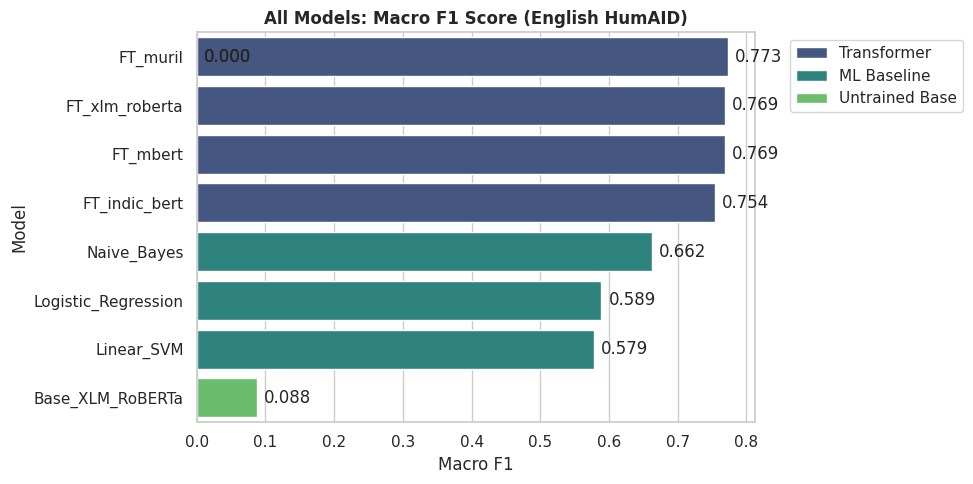

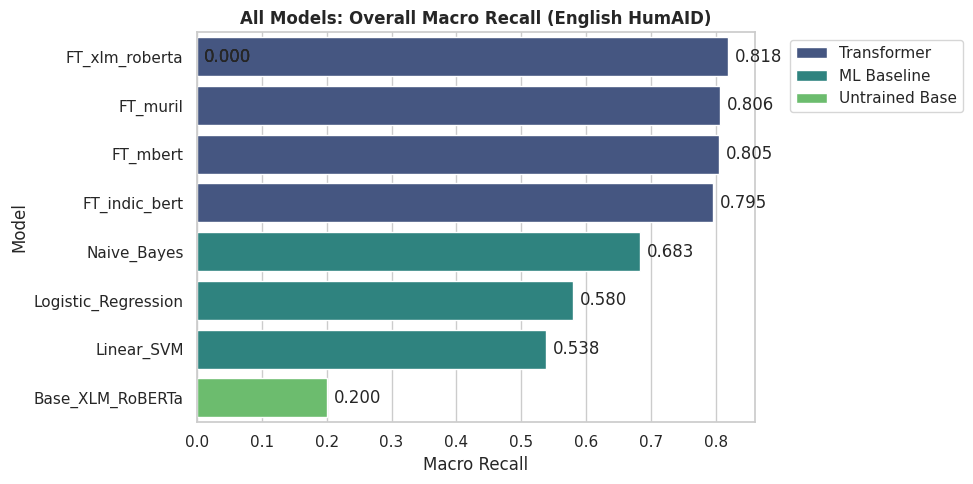

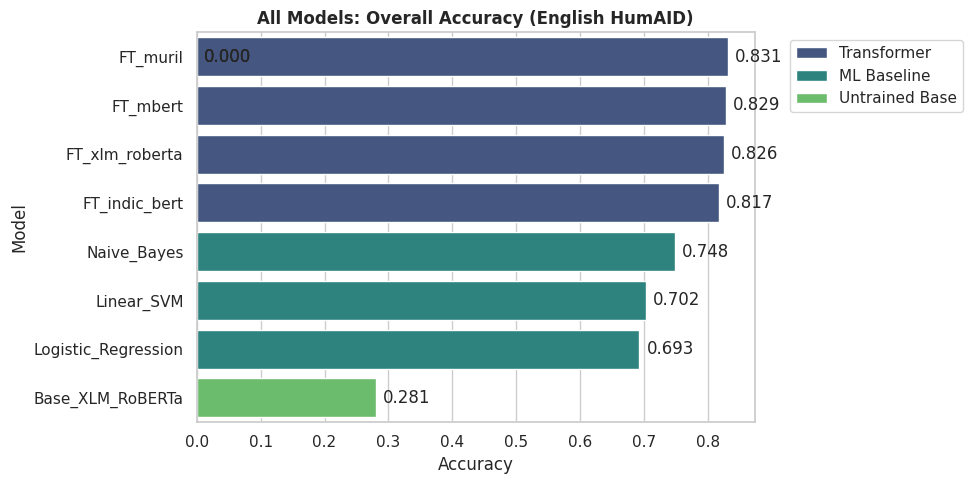

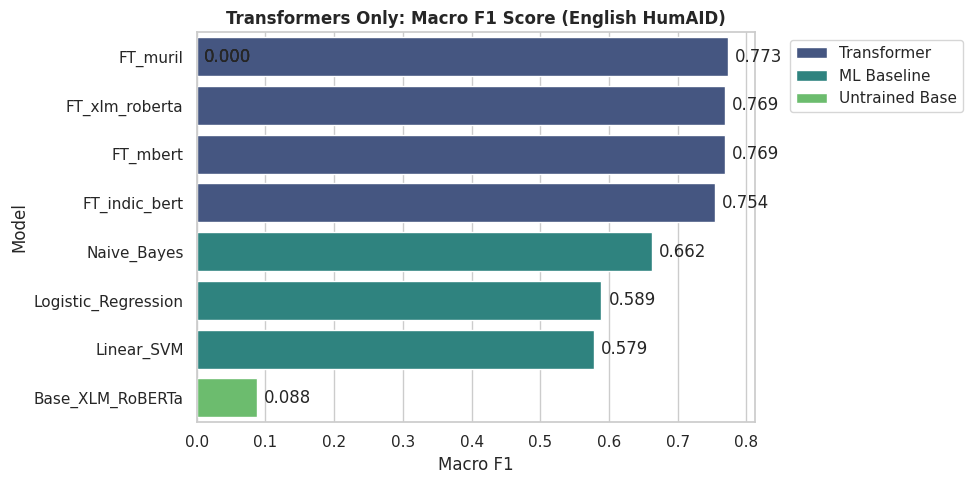

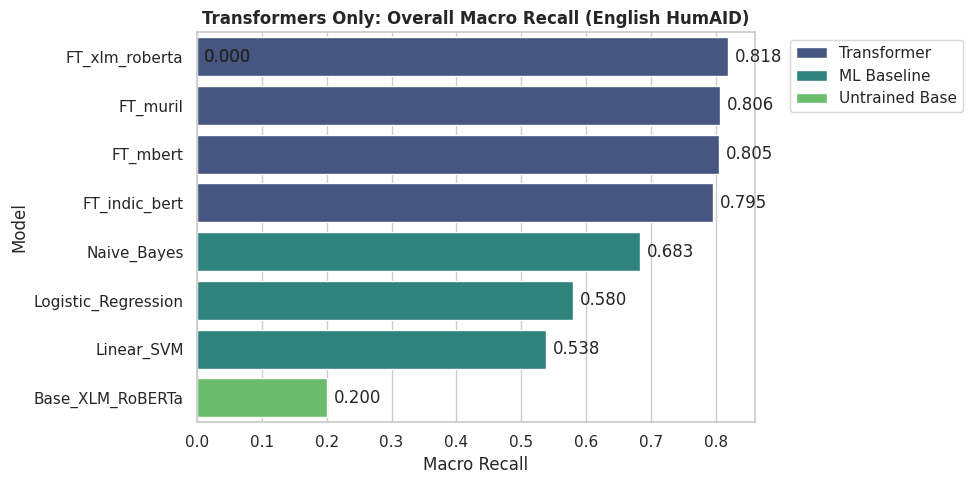

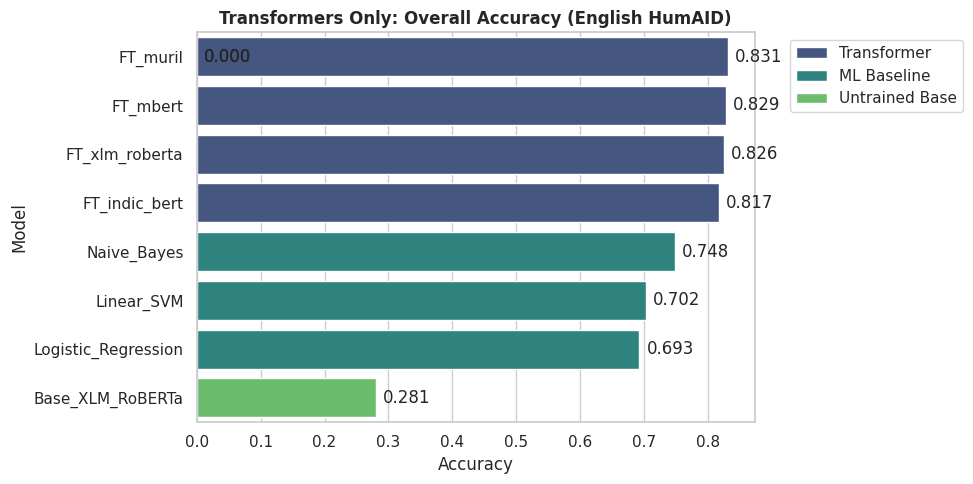

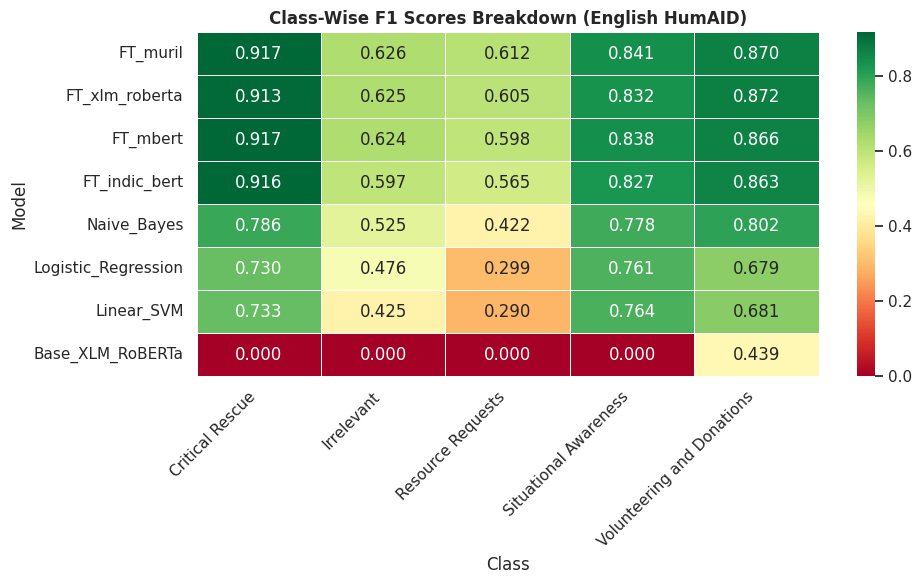

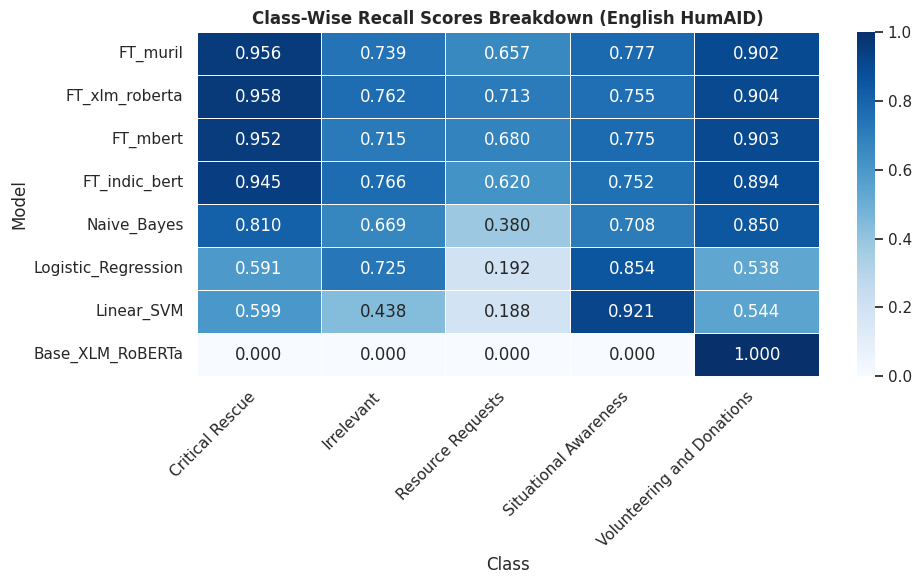


All plots and CSVs successfully saved to: /home/aakash/rizwan/NLP_Project/results/jupyter_plots_english_20260423_093528


In [5]:
# ==========================================
# CELL 3: Setup, Evaluate, Plot, and Save (ENGLISH HUMAID DATASET)
# ==========================================
import os
import torch
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm  # Uses Jupyter-friendly progress bars
from datetime import datetime
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import warnings
warnings.filterwarnings('ignore')

# 1. Setup Paths for Jupyter
ROOT_DIR = os.path.abspath("..") 
# IMPORTANT: Pointing back to the original English HumAID dataset
DATA_PATH = os.path.join(ROOT_DIR, "datasets", "processed", "humaid_processed.csv")
ML_MODELS_DIR = os.path.join(ROOT_DIR, "offline_models", "ml_baselines")
RESULTS_DIR = os.path.join(ROOT_DIR, "results")

# Generate a timestamped folder just for these English plots
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
PLOT_DIR = os.path.join(RESULTS_DIR, f"jupyter_plots_english_{TIMESTAMP}")
os.makedirs(PLOT_DIR, exist_ok=True)

LABEL_NAMES = ['Situational Awareness', 'Critical Rescue', 'Volunteering and Donations', 'Irrelevant', 'Resource Requests']
label2id = {label: i for i, label in enumerate(LABEL_NAMES)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating using device: {device}")
print(f"Reading dataset from: {DATA_PATH}")
print(f"Plots will be saved to: {PLOT_DIR}\n")

# 2. Evaluation Functions
def evaluate_ml_models(df):
    predictions_dict = {}
    print("--- Evaluating Traditional ML Baselines ---")
    vectorizer_path = os.path.join(ML_MODELS_DIR, "tfidf_vectorizer.joblib")
    if not os.path.exists(vectorizer_path):
        return predictions_dict
        
    vectorizer = joblib.load(vectorizer_path)
    X_test = vectorizer.transform(df['text'].astype(str).fillna(''))
    y_test = df['label_id'].values

    for model_name in ["Logistic_Regression", "Linear_SVM", "Random_Forest", "Naive_Bayes"]:
        model_path = os.path.join(ML_MODELS_DIR, f"{model_name}.joblib")
        if os.path.exists(model_path):
            print(f"Evaluating {model_name}...")
            model = joblib.load(model_path)
            y_pred = model.predict(X_test)
            y_pred_ids = [label2id.get(label, -1) for label in y_pred]
            predictions_dict[model_name] = {"y_true": y_test, "y_pred": y_pred_ids, "type": "ML Baseline"}
    return predictions_dict

def evaluate_transformer(model_name, model_path, df, model_type="Transformer"):
    print(f"--- Evaluating {model_type}: {model_name} ---")
    if not os.path.exists(model_path): return None

    use_fast = False if "indic_bert" in model_name.lower() else True
    tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=use_fast)
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=5).to(device)
    model.eval()

    texts = df['text'].astype(str).tolist()
    y_true = df['label_id'].values
    y_pred = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), 32), desc=model_name):
            inputs = tokenizer(texts[i:i+32], padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
            logits = model(**inputs).logits
            y_pred.extend(torch.argmax(logits, dim=-1).cpu().numpy())

    del model, tokenizer
    torch.cuda.empty_cache()
    return {"y_true": list(y_true), "y_pred": list(y_pred), "type": model_type}

# 3. Execution (UPDATED FOR ENGLISH DATASET)
full_df = pd.read_csv(DATA_PATH)

# Filter for the test split
if 'test' in full_df['split'].values:
    df = full_df[full_df['split'] == 'test'].copy()
else:
    df = full_df[full_df['split'] == 'dev'].copy()

# Map the English column names so the evaluation functions can read them
df['label_id'] = df['target_label'].map(label2id)
df['text'] = df['clean_text'] # Standardizing the text column name
df = df.dropna(subset=['label_id', 'text'])
df['label_id'] = df['label_id'].astype(int)

print(f"Evaluating on {len(df)} English test samples...\n")

model_predictions = evaluate_ml_models(df)

transformers = ["local_muril", "local_indic_bert", "local_mbert", "local_xlm_roberta"]
for t_name in transformers:
    dirs = [d for d in os.listdir(RESULTS_DIR) if t_name in d and os.path.isdir(os.path.join(RESULTS_DIR, d, "final_model"))]
    if dirs:
        t_path = os.path.join(RESULTS_DIR, sorted(dirs)[-1], "final_model")
        res = evaluate_transformer(f"FT_{t_name.replace('local_', '')}", t_path, df)
        if res: model_predictions[f"FT_{t_name.replace('local_', '')}"] = res

res_base = evaluate_transformer("Base_XLM_RoBERTa", os.path.join(ROOT_DIR, "offline_models", "local_xlm_roberta"), df, "Untrained Base")
if res_base: model_predictions["Base_XLM_RoBERTa"] = res_base

# 4. Process Metrics
overall_metrics, class_f1_scores, class_recall_scores = [], [], []

for name, data in model_predictions.items():
    yt, yp, mtype = data['y_true'], data['y_pred'], data['type']
    p, r, f1, _ = precision_recall_fscore_support(yt, yp, average='macro', zero_division=0)
    acc = accuracy_score(yt, yp)
    overall_metrics.append({"Model": name, "Type": mtype, "Accuracy": acc, "Macro Recall": r, "Macro F1": f1})
    
    _, class_r, class_f1, _ = precision_recall_fscore_support(yt, yp, labels=range(5), zero_division=0)
    for i, class_name in enumerate(LABEL_NAMES):
        class_f1_scores.append({"Model": name, "Class": class_name, "Score": class_f1[i]})
        class_recall_scores.append({"Model": name, "Class": class_name, "Score": class_r[i]})

results_df = pd.DataFrame(overall_metrics).sort_values("Macro F1", ascending=False)
f1_df = pd.DataFrame(class_f1_scores).pivot(index="Model", columns="Class", values="Score").reindex(results_df["Model"])
recall_df = pd.DataFrame(class_recall_scores).pivot(index="Model", columns="Class", values="Score").reindex(results_df["Model"])

# Save the raw metrics to CSVs as well
results_df.to_csv(os.path.join(PLOT_DIR, "overall_metrics_english.csv"), index=False)
f1_df.to_csv(os.path.join(PLOT_DIR, "classwise_f1_english.csv"))
recall_df.to_csv(os.path.join(PLOT_DIR, "classwise_recall_english.csv"))

# ==========================================
# 5. INLINE PLOTTING AND SAVING
# ==========================================
sns.set_theme(style="whitegrid")

def plot_bar(data, x_col, title, filename):
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=data, x=x_col, y="Model", hue="Type", dodge=False, palette="viridis")
    plt.title(title, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    for p in ax.patches:
        if not np.isnan(p.get_width()):
            ax.annotate(f"{p.get_width():.3f}", (p.get_width(), p.get_y() + p.get_height() / 2.), xytext=(5, 0), textcoords='offset points', va='center')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, filename), dpi=300, bbox_inches='tight') 
    plt.show()

def plot_heatmap(data, title, filename, cmap="RdYlGn"):
    plt.figure(figsize=(10, 6))
    sns.heatmap(data, annot=True, cmap=cmap, fmt='.3f', linewidths=.5)
    plt.title(title, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, filename), dpi=300, bbox_inches='tight')
    plt.show()

# A. ALL MODELS: F1, Recall, & Accuracy
plot_bar(results_df, "Macro F1", "All Models: Macro F1 Score (English HumAID)", "all_models_f1_english.png")
plot_bar(results_df.sort_values("Macro Recall", ascending=False), "Macro Recall", "All Models: Overall Macro Recall (English HumAID)", "all_models_recall_english.png")
plot_bar(results_df.sort_values("Accuracy", ascending=False), "Accuracy", "All Models: Overall Accuracy (English HumAID)", "all_models_accuracy_english.png")

# B. TRANSFORMERS ONLY: F1, Recall, & Accuracy
transformers_df = results_df[results_df["Type"].str.contains("Transformer|Base")]
plot_bar(transformers_df, "Macro F1", "Transformers Only: Macro F1 Score (English HumAID)", "transformers_only_f1_english.png")
plot_bar(transformers_df.sort_values("Macro Recall", ascending=False), "Macro Recall", "Transformers Only: Overall Macro Recall (English HumAID)", "transformers_only_recall_english.png")
plot_bar(transformers_df.sort_values("Accuracy", ascending=False), "Accuracy", "Transformers Only: Overall Accuracy (English HumAID)", "transformers_only_accuracy_english.png")

# C. CLASS-WISE HEATMAPS (All Models)
plot_heatmap(f1_df, "Class-Wise F1 Scores Breakdown (English HumAID)", "classwise_f1_heatmap_english.png")
plot_heatmap(recall_df, "Class-Wise Recall Scores Breakdown (English HumAID)", "classwise_recall_heatmap_english.png", cmap="Blues")

print(f"\nAll plots and CSVs successfully saved to: {PLOT_DIR}")

Loading MuRIL from: /home/aakash/rizwan/NLP_Project/results/local_muril_20260423_041201/final_model


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_muril_20260423_041201/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Extracting Embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

Running t-SNE dimensionality reduction...


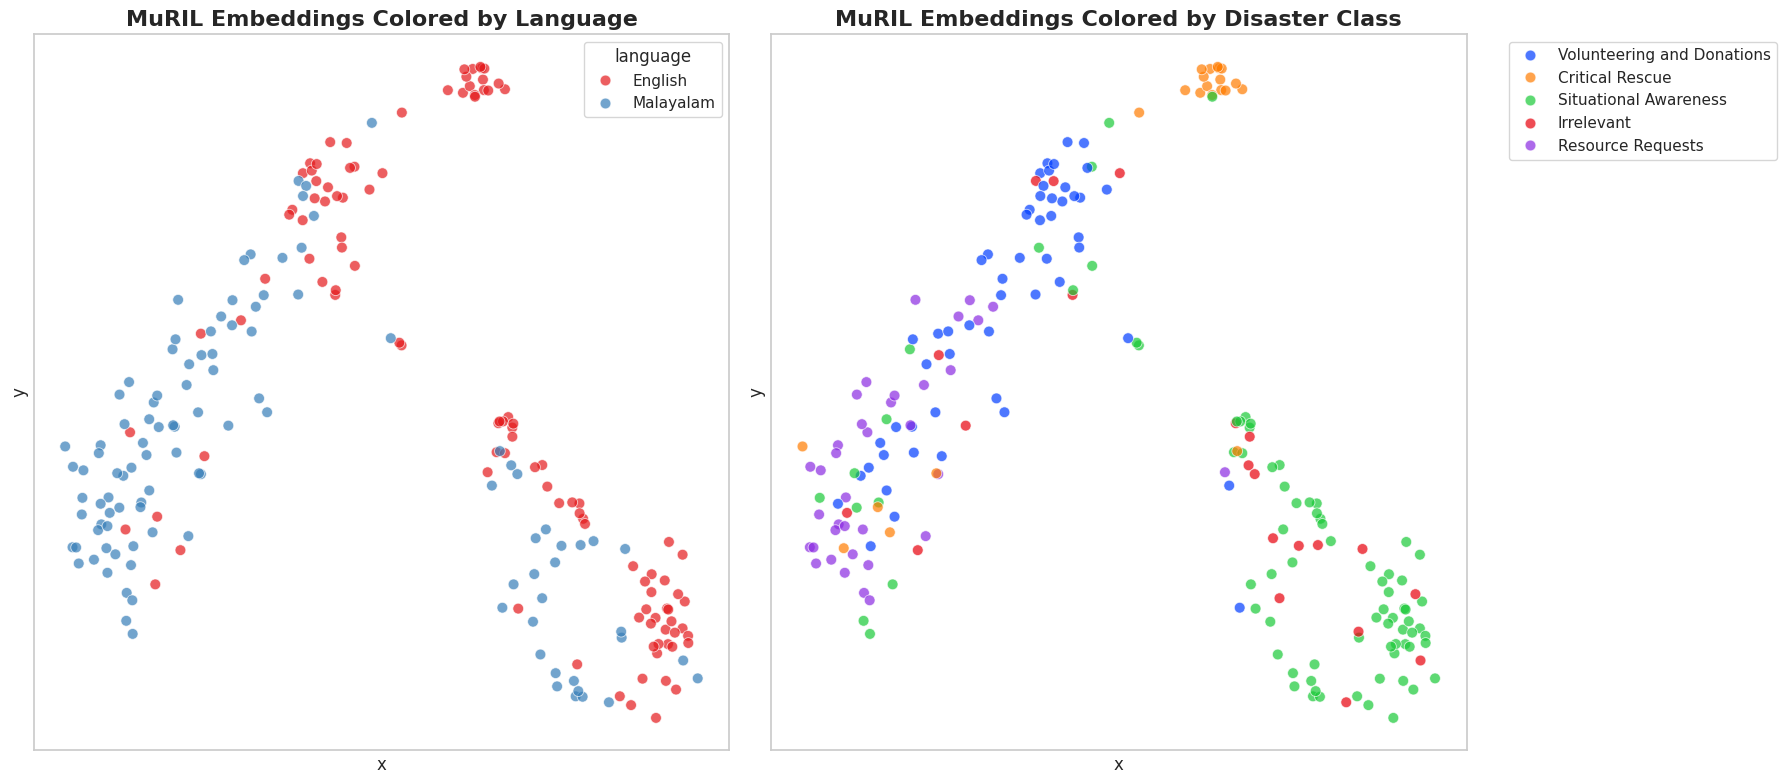


CROSS-LINGUAL COSINE SIMILARITY TEST
English:    'We need urgent rescue from the flood, please help!'
Malayalam: 'പ്രളയത്തിൽ നിന്നും ഞങ്ങളെ അടിയന്തരമായി രക്ഷിക്കണം, ദയവായി സഹായിക്കുക!'

Cosine Similarity Score: 0.8654 / 1.0


In [8]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT_DIR = os.path.abspath("..") 
ENG_PATH = os.path.join(ROOT_DIR, "datasets", "processed", "humaid_processed.csv")
MAL_PATH = os.path.join(ROOT_DIR, "datasets", "processed", "malayalam_cleaned.csv")
RESULTS_DIR = os.path.join(ROOT_DIR, "results")

muril_dirs = [d for d in os.listdir(RESULTS_DIR) if "local_muril" in d and os.path.isdir(os.path.join(RESULTS_DIR, d, "final_model"))]
if not muril_dirs:
    raise FileNotFoundError("Could not find a local_muril directory in results/!")
MODEL_PATH = os.path.join(RESULTS_DIR, sorted(muril_dirs)[-1], "final_model")
print(f"Loading MuRIL from: {MODEL_PATH}")

df_eng_full = pd.read_csv(ENG_PATH)
df_eng_full = df_eng_full[df_eng_full['split'] == 'test']

df_mal_full = pd.read_csv(MAL_PATH)

sample_size = min(500, len(df_mal_full), len(df_eng_full))

df_eng = df_eng_full.sample(sample_size, random_state=42)
df_eng['language'] = 'English'
df_eng['text'] = df_eng['clean_text']

df_mal = df_mal_full.sample(sample_size, random_state=42)
df_mal['language'] = 'Malayalam'

df_plot = pd.concat([
    df_eng[['text', 'target_label', 'language']], 
    df_mal[['text', 'label', 'language']].rename(columns={'label': 'target_label'})
]).dropna()

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModel.from_pretrained(MODEL_PATH).to(device)
model.eval()

embeddings = []
texts = df_plot['text'].astype(str).tolist()

with torch.no_grad():
    for i in tqdm(range(0, len(texts), 32), desc="Extracting Embeddings"):
        inputs = tokenizer(texts[i:i+32], padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.extend(cls_embeddings)

print("Running t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_array = np.array(embeddings)
embeddings_2d = tsne.fit_transform(embeddings_array)

df_plot['x'] = embeddings_2d[:, 0]
df_plot['y'] = embeddings_2d[:, 1]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.scatterplot(data=df_plot, x='x', y='y', hue='language', palette="Set1", s=60, alpha=0.7, ax=axes[0])
axes[0].set_title("MuRIL Embeddings Colored by Language", fontsize=16, fontweight='bold')
axes[0].set_xticks([])
axes[0].set_yticks([])

sns.scatterplot(data=df_plot, x='x', y='y', hue='target_label', palette="bright", s=60, alpha=0.7, ax=axes[1])
axes[1].set_title("MuRIL Embeddings Colored by Disaster Class", fontsize=16, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("CROSS-LINGUAL COSINE SIMILARITY TEST")
print("="*50)

english_tweet = "We need urgent rescue from the flood, please help!"
malayalam_tweet = "പ്രളയത്തിൽ നിന്നും ഞങ്ങളെ അടിയന്തരമായി രക്ഷിക്കണം, ദയവായി സഹായിക്കുക!"

with torch.no_grad():
    inputs_eng = tokenizer(english_tweet, return_tensors="pt", truncation=True, max_length=128).to(device)
    inputs_mal = tokenizer(malayalam_tweet, return_tensors="pt", truncation=True, max_length=128).to(device)
    
    vec_eng = model(**inputs_eng).last_hidden_state[:, 0, :].cpu().numpy()
    vec_mal = model(**inputs_mal).last_hidden_state[:, 0, :].cpu().numpy()

similarity = cosine_similarity(vec_eng, vec_mal)[0][0]

print(f"English:    '{english_tweet}'")
print(f"Malayalam: '{malayalam_tweet}'\n")
print(f"Cosine Similarity Score: {similarity:.4f} / 1.0")